In [8]:
!pip install medmnist

In [9]:
! pip install -q neptune

In [10]:
from tqdm import tqdm
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision import models
import neptune

import medmnist
from medmnist import INFO, Evaluator

In [11]:
NEPTUNE_PROJECT_NAME = "sigk/data-generation"
NEPTUNE_API_KEY = input("Enter Neptune API key: ")

Enter Neptune API key: eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiJlZmIwZTU3OS0xZmJjLTRiZjEtODZmNS0yOGI2NjI1ZjE4NDgifQ==


In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [13]:
# data_flag = 'bloodmnist'
data_flag = 'dermamnist'
# data_flag = 'pathmnist'
download = True

NUM_EPOCHS = 10
BATCH_SIZE = 128
lr = 0.001

info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

DataClass = getattr(medmnist, info['python_class'])

In [14]:
# # preprocessing
# data_transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[.5], std=[.5])
# ])

# # load the data
# train_dataset = DataClass(split='train', transform=data_transform, download=download)
# test_dataset = DataClass(split='test', transform=data_transform, download=download)

# pil_dataset = DataClass(split='train', download=download)

# # encapsulate data into dataloader form
# train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# train_loader_at_eval = data.DataLoader(dataset=train_dataset, batch_size=2*BATCH_SIZE, shuffle=False)
# test_loader = data.DataLoader(dataset=test_dataset, batch_size=2*BATCH_SIZE, shuffle=False)


In [15]:
# print(train_dataset)
# print("===================")
# print(test_dataset)

In [16]:
# visualization

# train_dataset.montage(length=1)

In [17]:
# montage

# train_dataset.montage(length=20)

In [18]:
# class MedModel(nn.Module):
#     def __init__(self, in_channels, num_classes):
#         super(MedModel, self).__init__()

#         # 1. Pobierz model z wagami ImageNet
#         self.model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
#         for param in self.model.parameters():
#           param.requires_grad = False

#         # 2. Zmniejsz kernel i stride w conv1 (dla małych obrazków)
#         # self.model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)

#         # 3. Wywal maxpool, bo dla małych obrazów zjada za dużo informacji
#         # self.model.maxpool = nn.Identity()

#         # 4. Zamień ostatnią warstwę FC na własną
#         in_features = self.model.fc.in_features
#         self.model.fc = nn.Linear(in_features, num_classes)

#     def forward(self, x):
#         return self.model(x)

# model = MedModel(in_channels=n_channels, num_classes=n_classes)

# # define loss function and optimizer
# if task == "multi-label, binary-class":
#     criterion = nn.BCEWithLogitsLoss()
# else:
#     criterion = nn.CrossEntropyLoss()

# params_to_update = [p for p in model.parameters() if p.requires_grad]
# optimizer = optim.Adam(params_to_update, lr=lr)

In [19]:
# # train
# model = model.to(device)


# for epoch in range(NUM_EPOCHS):
#     train_correct = 0
#     train_total = 0
#     test_correct = 0
#     test_total = 0

#     model.train()
#     for inputs, targets in tqdm(train_loader):
#         inputs = inputs.to(device)
#         targets = targets.to(device)
#         # forward + backward + optimize
#         optimizer.zero_grad()
#         outputs = model(inputs)

#         if task == 'multi-label, binary-class':
#             targets = targets.to(torch.float32)
#             loss = criterion(outputs, targets)
#         else:
#             targets = targets.squeeze().long()
#             loss = criterion(outputs, targets)

#         loss.backward()
#         optimizer.step()

In [20]:
# # evaluation

# def test(split):
#     model.eval()
#     y_true = torch.tensor([])
#     y_score = torch.tensor([])
#     y_true = y_true.to(device)
#     y_score = y_score.to(device)

#     data_loader = train_loader_at_eval if split == 'train' else test_loader

#     with torch.no_grad():
#         for inputs, targets in data_loader:
#             inputs = inputs.to(device)
#             targets = targets.to(device)
#             outputs = model(inputs)

#             if task == 'multi-label, binary-class':
#                 targets = targets.to(torch.float32)
#                 outputs = outputs.softmax(dim=-1)
#             else:
#                 targets = targets.squeeze().long()
#                 outputs = outputs.softmax(dim=-1)
#                 targets = targets.float().resize_(len(targets), 1)

#             y_true = torch.cat((y_true, targets), 0)
#             y_score = torch.cat((y_score, outputs), 0)

#         y_true = y_true.cpu().numpy()
#         y_score = y_score.detach().cpu().numpy()

#         evaluator = Evaluator(data_flag, split)
#         metrics = evaluator.evaluate(y_score)

#         print('%s  auc: %.3f  acc:%.3f' % (split, *metrics))


# print('==> Evaluating ...')
# test('train')
# test('test')

In [21]:
data_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),  # skaluje do [0, 1] automatycznie
])

# load the data
train_dataset = DataClass(split='train', transform=data_transform, download=download)
test_dataset = DataClass(split='test', transform=data_transform, download=download)

pil_dataset = DataClass(split='train', download=download)

# encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
train_loader_at_eval = data.DataLoader(dataset=train_dataset, batch_size=2*BATCH_SIZE, shuffle=False)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=2*BATCH_SIZE, shuffle=False)

In [22]:
train_dataset.montage(length=1)

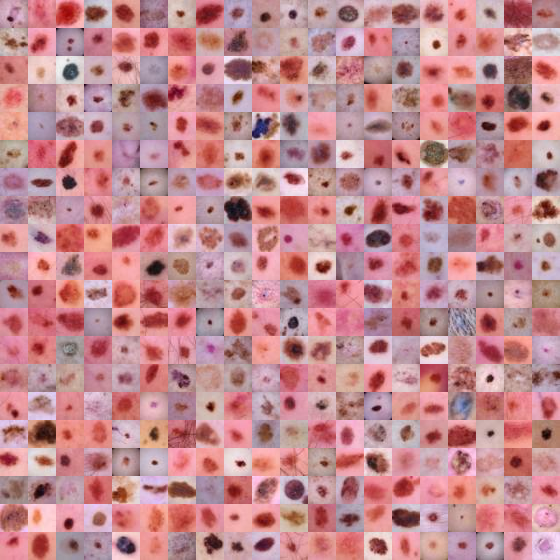

In [23]:
train_dataset.montage(length=20)

In [24]:
class Generator(nn.Module):
    def __init__(
        self,
        latent_dim: int = 100,
        output_channels: int = 3,
        output_size: int = 64
    ):
        super().__init__()
        assert output_size % 16 == 0, "Output size must be divisible by 16 (e.g., 64, 128)"

        self.latent_dim = latent_dim
        self.output_size = output_size
        self.output_channels = output_channels
        self.init_size = output_size // 16  # Initial feature map size (e.g., 4x4 if 64x64 output)

        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 256 * self.init_size * self.init_size),
            nn.ReLU(True)
        )

        self.upsample = nn.Sequential(
            nn.Upsample(scale_factor=2),  # 4 -> 8
            nn.Conv2d(256, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2),  # 8 -> 16
            nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2),  # 16 -> 32
            nn.Conv2d(64, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2),  # 32 -> 64
            nn.Conv2d(32, output_channels, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid()  # or Tanh if your data is scaled to [-1, 1]
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        out = self.fc(z)
        out = out.view(z.size(0), 256, self.init_size, self.init_size)
        img = self.upsample(out)
        return img

In [25]:
model = Generator(latent_dim=100, output_channels=3, output_size=64)

for images, labels in train_loader:
    print("Images shape (real):", images.shape)  # np. [128, 3, 64, 64] po preprocessing

    batch_size = images.size(0)
    latent_dim = 100
    z = torch.randn(batch_size, latent_dim)  # [128, 100]

    output = model(z)  # [128, 3, 64, 64]
    print("Generated image shape:", output.shape)
    break

Images shape (real): torch.Size([128, 3, 64, 64])
Generated image shape: torch.Size([128, 3, 64, 64])


In [26]:
class Discriminator(nn.Module):
    def __init__(
        self,
        input_channels: int = 3,
        input_size: int = 64
    ):
        super().__init__()
        assert input_size % 16 == 0, "Input size must be divisible by 16 (e.g., 64, 128)"

        self.input_channels = input_channels
        self.input_size = input_size
        self.final_size = input_size // 16  # Zakładamy 4 kroki downsamplingu: 64 → 32 → 16 → 8 → 4

        self.features = nn.Sequential(
            nn.Conv2d(input_channels, 64, kernel_size=4, stride=2, padding=1),  # 64x64 → 32x32
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),  # 32x32 → 16x16
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),  # 16x16 → 8x8
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),  # 8x8 → 4x4
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * self.final_size * self.final_size, 1),
            nn.Sigmoid()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        out = self.classifier(x)
        return out

In [27]:
import torch
import torchvision

def train_gan(
    generator: nn.Module,
    discriminator: nn.Module,
    optimizer_G: optim.Optimizer,
    optimizer_D: optim.Optimizer,
    adversarial_loss: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    num_epochs: int = 20,
    latent_dim: int = 100,
    lambda_l1: float = 100.0,
    run: 'neptune.Run' = None,
    device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
) -> None:
    generator = generator.to(device)
    discriminator = discriminator.to(device)
    l1_loss = nn.L1Loss()

    for epoch in range(num_epochs):
        generator.train()
        discriminator.train()
        total_g_loss = 0.0
        total_d_loss = 0.0

        for real_images, _ in train_loader:  # etykiety niepotrzebne
            real_images = real_images.to(device)
            batch_size = real_images.size(0)

            # === Etap 1: TRENUJEMY DYSKRYMINATORA ===
            optimizer_D.zero_grad()

            # Dane rzeczywiste
            real_labels = torch.full((batch_size, 1), 0.9, device=device)  # label smoothing
            real_preds = discriminator(real_images)
            real_loss = adversarial_loss(real_preds, real_labels)

            # Dane sztuczne
            z = torch.randn(batch_size, latent_dim, device=device)
            fake_images = generator(z).detach()  # odłączone od gradientów Generatora
            fake_labels = torch.zeros((batch_size, 1), device=device)
            fake_preds = discriminator(fake_images)
            fake_loss = adversarial_loss(fake_preds, fake_labels)

            # Całkowita strata dyskryminatora
            d_loss = (real_loss + fake_loss) / 2
            d_loss.backward()
            optimizer_D.step()

            # === Etap 2: TRENUJEMY GENERATOR ===
            optimizer_G.zero_grad()

            z = torch.randn(batch_size, latent_dim, device=device)
            generated_images = generator(z)
            preds = discriminator(generated_images)

            g_loss_adv = adversarial_loss(preds, real_labels)  # generator chce oszukać dyskryminator
            g_loss_l1 = l1_loss(generated_images, real_images)
            g_loss = g_loss_adv + lambda_l1 * g_loss_l1
            g_loss.backward()
            optimizer_G.step()

            # === Logging ===
            total_g_loss += g_loss.item()
            total_d_loss += d_loss.item()

            if run:
                run["train/step/g_loss"].append(g_loss.item())
                run["train/step/d_loss"].append(d_loss.item())

        avg_g_loss = total_g_loss / len(train_loader)
        avg_d_loss = total_d_loss / len(train_loader)
        print(f"[Epoch {epoch+1}] G Loss: {avg_g_loss:.4f} | D Loss: {avg_d_loss:.4f}")

        if run:
            run["train/epoch/g_loss"].append(avg_g_loss)
            run["train/epoch/d_loss"].append(avg_d_loss)

            # Przykładowe wygenerowane obrazki - korzystamy z funkcji plot_predictions
            generator.eval()
            with torch.no_grad():
              z = torch.randn(16, latent_dim, device=device)
              fig = plot_predictions_gan(generator, val_loader=val_loader, n=4, latent_dim=latent_dim, device=device, show=False)
              run[f"train/epoch/{epoch+1}_samples"].upload(neptune.types.File.as_image(fig))


In [28]:
import matplotlib.pyplot as plt
import torch

def plot_predictions_gan(
    model: torch.nn.Module,
    val_loader: torch.utils.data.DataLoader,
    n: int = 5,
    latent_dim: int = 100,
    device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    show: bool = True
) -> plt.Figure:
    model.eval()  # Ustaw model w tryb ewaluacji
    fig, axes = plt.subplots(2, n, figsize=(2 * n, 4))  # Dwa wiersze dla Ground Truth i Prediction

    with torch.no_grad():
        for i, (real_images, _) in enumerate(val_loader):
            if i >= n:
                break

            real_images = real_images.to(device)

            # Generowanie obrazków z szumu
            z = torch.randn(real_images.size(0), latent_dim, device=device)  # Generujemy z losowego szumu
            generated_images = model(z)

            # Pierwszy wiersz: prawdziwe obrazy (Ground Truth)
            ax_gt = axes[0, i]
            ax_gt.imshow(real_images[i].cpu().permute(1, 2, 0).numpy())  # Prawdziwy obraz
            ax_gt.set_title(f"Real {i+1}")

            # Drugi wiersz: wygenerowane obrazy
            ax_pred = axes[1, i]
            ax_pred.imshow(generated_images[i].cpu().permute(1, 2, 0).numpy())  # Wygenerowany obraz
            ax_pred.set_title(f"Generated {i+1}")

        # Układ etykiet
        axes[0, 0].set_ylabel('Ground Truth', fontsize=12, fontweight='bold')
        axes[1, 0].set_ylabel('Generated', fontsize=12, fontweight='bold')

        for ax in axes.flat:
            ax.set_xticks([])
            ax.set_yticks([])

    plt.tight_layout(pad=0.5)
    if show:
        plt.show()

    plt.close()
    return fig


In [29]:
# device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# G = Generator()
# D = Discriminator()
# G = G.to(device)
# D = D.to(device)

# lr_G = 1e-4
# lr_D = 1e-5
# optimizer_G = optim.Adam(G.parameters(), lr=lr_G, betas=(0.5, 0.999))
# optimizer_D = optim.Adam(D.parameters(), lr=lr_G, betas=(0.5, 0.999))
# epochs=200
# lambda_l1=100

# adversarial_loss = nn.MSELoss()
# # adversarial_loss = nn.BCEWithLogitsLoss()

In [30]:
# run = neptune.init_run(
#     project=NEPTUNE_PROJECT_NAME,
#     api_token=NEPTUNE_API_KEY,
# )
# params = {
#     "generator_name": G.__class__.__name__,
#     "discriminator_name": D.__class__.__name__,
#     "generator_optimizer_name": optimizer_G.__class__.__name__,
#     "discriminator_optimizer_name": optimizer_D.__class__.__name__,
#     "generator_learning_rate": lr_G,
#     "discriminator_learning_rate": lr_D,
#     "adversarial_loss": adversarial_loss.__class__.__name__,
#     "lambda_l1": lambda_l1,
#     "epochs": epochs,
#     "dataset_size": len(train_dataset),
#     "dataset_version": data_flag,
#     "batch_size": batch_size,
# }
# run["parameters"] = params

In [31]:
# run.stop()

In [32]:
import os
from datetime import datetime
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.utils import save_image

In [33]:
# start_time = datetime.now()
# train_gan(
#     G,
#     D,
#     optimizer_G,
#     optimizer_D,
#     adversarial_loss=adversarial_loss,
#     train_loader=train_loader,
#     val_loader=train_loader_at_eval,
#     lambda_l1=lambda_l1,
#     num_epochs=epochs,
#     run=run,
# )
# train_time = datetime.now() - start_time
# print(f"Training time: {train_time}")
# run["train/time"] = train_time.seconds

In [47]:
import torch.nn as nn
import torch.nn.functional as F

class Encoder(nn.Module):
    def __init__(self, latent_dim=256, input_channels=3, input_size=64):
        super().__init__()
        self.latent_dim = latent_dim
        self.input_size = input_size
        self.final_size = input_size // 16

        self.conv = nn.Sequential(
            nn.Conv2d(input_channels, 128, 4, stride=2, padding=1),  # 64->32
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, stride=2, padding=1),             # 32->16
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.Conv2d(256, 512, 4, stride=2, padding=1),             # 16->8
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),
            nn.Conv2d(512, 1024, 4, stride=2, padding=1),            # 8->4
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.2),
        )

        self.fc_mu = nn.Sequential(
            nn.Linear(1024 * self.final_size * self.final_size, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, latent_dim),
        )
        self.fc_logvar = nn.Sequential(
            nn.Linear(1024 * self.final_size * self.final_size, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, latent_dim),
        )

    def forward(self, x):
        batch_size = x.size(0)
        x = self.conv(x)
        x = x.view(batch_size, -1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar


In [48]:
class Decoder(nn.Module):
    def __init__(self, latent_dim=256, output_channels=3, output_size=64):
        super().__init__()
        assert output_size % 16 == 0

        self.latent_dim = latent_dim
        self.output_size = output_size
        self.output_channels = output_channels
        self.init_size = output_size // 16

        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024 * self.init_size * self.init_size),
            nn.LeakyReLU(0.2),
        )

        self.upsample = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.Conv2d(1024, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),

            nn.Upsample(scale_factor=2),
            nn.Conv2d(512, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Upsample(scale_factor=2),
            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, output_channels, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, z):
        out = self.fc(z)
        out = out.view(z.size(0), 1024, self.init_size, self.init_size)
        img = self.upsample(out)
        return img

In [49]:
def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std


In [50]:
def vae_loss(recon_x, x, mu, logvar):
    # Rekonstrukcja (np. BCE)
    recon_loss = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    # KL Divergencja
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kld, recon_loss, kld


In [51]:
!pip install pytorch-msssim

In [52]:
from pytorch_msssim import ssim
import torch.nn.functional as F

def vae_loss_with_ssim(recon_x, x, mu, logvar, alpha=0.5):
    bce = F.binary_cross_entropy(recon_x, x, reduction='sum')
    ssim_loss = 1 - ssim(recon_x, x, data_range=1.0, size_average=False).sum()
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return alpha * bce + (1 - alpha) * ssim_loss + kld, bce, ssim_loss, kld


In [53]:
def train_vae(
    encoder: nn.Module,
    decoder: nn.Module,
    optimizer: torch.optim.Optimizer,
    train_loader,
    val_loader,
    num_epochs: int = 20,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    run=None,
    latent_dim: int = 100,
):
    encoder.to(device)
    decoder.to(device)

    for epoch in range(num_epochs):
        encoder.train()
        decoder.train()

        total_loss = 0.0
        recon_loss_sum = 0.0
        kld_loss_sum = 0.0
        ssim_loss_sum = 0.0

        for imgs, _ in train_loader:
            imgs = imgs.to(device)
            optimizer.zero_grad()

            mu, logvar = encoder(imgs)
            z = reparameterize(mu, logvar)
            outputs = decoder(z)

            loss, recon_loss, ssim_loss, kld = vae_loss_with_ssim(outputs, imgs, mu, logvar)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            recon_loss_sum += recon_loss.item()
            kld_loss_sum += kld.item()
            ssim_loss_sum += ssim_loss.item()

        avg_loss = total_loss / len(train_loader.dataset)
        avg_recon = recon_loss_sum / len(train_loader.dataset)
        avg_kld = kld_loss_sum / len(train_loader.dataset)
        avg_ssim = ssim_loss_sum / len(train_loader.dataset)


        print(f"Epoch {epoch+1}: Loss {avg_loss:.4f}, Recon {avg_recon:.4f}, KLD {avg_kld:.4f}")

        if run:
            run["train/epoch/loss"].append(avg_loss)
            run["train/epoch/recon"].append(avg_recon)
            run["train/epoch/kld"].append(avg_kld)

            encoder.eval()
            decoder.eval()
            with torch.no_grad():
                fig = plot_predictions_vae(
                    encoder,
                    decoder,
                    val_loader=val_loader,
                    n=4,
                    latent_dim=latent_dim,
                    device=device,
                    show=False
                )
                run[f"train/epoch/{epoch+1}_samples"].upload(neptune.types.File.as_image(fig))
            encoder.train()
            decoder.train()


In [54]:
import matplotlib.pyplot as plt
import torch

def plot_predictions_vae(
    encoder: torch.nn.Module,
    decoder: torch.nn.Module,
    val_loader: torch.utils.data.DataLoader,
    n: int = 5,
    latent_dim: int = 100,
    device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    show: bool = True
) -> plt.Figure:
    encoder.eval()
    decoder.eval()

    fig, axes = plt.subplots(2, n, figsize=(2 * n, 4))  # 2 wiersze: oryginały i rekonstrukcje

    with torch.no_grad():
        for i, (real_images, _) in enumerate(val_loader):
            if i >= n:
                break

            real_images = real_images.to(device)

            # Zakładamy batch_size >= n, wybieramy pierwszy obraz z batcha
            x = real_images[0].unsqueeze(0)

            # Przepuszczamy przez enkoder -> reparametryzacja -> dekoder
            mu, logvar = encoder(x)
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            z = mu + eps * std
            recon = decoder(z)

            # Pierwszy wiersz: obraz oryginalny
            ax_gt = axes[0, i]
            img_gt = x[0].cpu().permute(1, 2, 0).numpy()
            ax_gt.imshow(img_gt)
            ax_gt.set_title(f"Real {i+1}")

            # Drugi wiersz: rekonstrukcja
            ax_recon = axes[1, i]
            img_recon = recon[0].cpu().permute(1, 2, 0).numpy()
            ax_recon.imshow(img_recon)
            ax_recon.set_title(f"Recon {i+1}")

        axes[0, 0].set_ylabel('Ground Truth', fontsize=12, fontweight='bold')
        axes[1, 0].set_ylabel('Reconstruction', fontsize=12, fontweight='bold')

        for ax in axes.flat:
            ax.set_xticks([])
            ax.set_yticks([])

    plt.tight_layout(pad=0.5)
    if show:
        plt.show()

    plt.close()
    return fig


In [55]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_dim = 256

encoder = Encoder(latent_dim=latent_dim, input_channels=3, input_size=64).to(device)
decoder = Decoder(latent_dim=latent_dim, output_channels=3, output_size=64).to(device)

lr = 1e-3
optimizer = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=lr)
epochs = 200


In [56]:
run = neptune.init_run(
    project=NEPTUNE_PROJECT_NAME,
    api_token=NEPTUNE_API_KEY,
)
params = {
    "encoder_name": encoder.__class__.__name__,
    "decoder_name": decoder.__class__.__name__,
    "optimizer_name": optimizer.__class__.__name__,
    "learning_rate": lr,
    "epochs": epochs,
    "dataset_size": len(train_dataset),
    "dataset_version": data_flag,
    "batch_size": batch_size,
}
run["parameters"] = params

[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/sigk/data-generation/e/DAT-10


In [57]:
from datetime import datetime

start_time = datetime.now()

train_vae(
    encoder=encoder,
    decoder=decoder,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=train_loader_at_eval,
    num_epochs=epochs,
    device=device,
    run=run,
    latent_dim=256
)

train_time = datetime.now() - start_time
print(f"Training time: {train_time}")
run["train/time"] = train_time.seconds


Epoch 1: Loss 212926543.0282, Recon 7763.0560, KLD 212922663.1120
Epoch 2: Loss 3764.5879, Recon 7437.8558, KLD 46.0281
Epoch 3: Loss 3745.5404, Recon 7407.6386, KLD 42.0986
Epoch 4: Loss 3733.8655, Recon 7385.3460, KLD 41.5762
Epoch 5: Loss 3728.0430, Recon 7374.7116, KLD 41.0745
Epoch 6: Loss 3719.3449, Recon 7361.9314, KLD 38.7704
Epoch 7: Loss 3715.9420, Recon 7355.2266, KLD 38.7225
Epoch 8: Loss 3709.9499, Recon 7347.1494, KLD 36.7713
Epoch 9: Loss 3709.2998, Recon 7345.0583, KLD 37.1679
Epoch 10: Loss 3706.5072, Recon 7339.8035, KLD 37.0040
Epoch 11: Loss 3701.9089, Recon 7332.6156, KLD 36.0017
Epoch 12: Loss 3701.8622, Recon 7332.1140, KLD 36.2062
Epoch 13: Loss 3702.8592, Recon 7333.0850, KLD 36.7178
Epoch 14: Loss 3700.8265, Recon 7330.2857, KLD 36.0860
Epoch 15: Loss 3699.3013, Recon 7327.7647, KLD 35.8223


KeyboardInterrupt: 

In [ ]:
run.stop()

In [ ]:
import matplotlib.pyplot as plt
import torchvision

decoder.eval()
with torch.no_grad():
    z = torch.randn(16, latent_dim).to(device)  # latent_dim taki sam jak w trenowaniu
    samples = decoder(z)  # [16, 3, 64, 64]

    # Tworzymy grid 4x4 z normalizacją do [0,1]
    grid_img = torchvision.utils.make_grid(samples, nrow=4, normalize=True)

    # Wyświetlamy obrazek
    plt.figure(figsize=(8,8))
    plt.imshow(grid_img.permute(1, 2, 0).cpu())
    plt.axis('off')
    plt.title('Generated samples from VAE')
    plt.show()
